In [1]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"ab121a81fb536037f0c3dd698d666bb2"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d theoviel/rsna-breast-cancer-256-pngs

Dataset URL: https://www.kaggle.com/datasets/theoviel/rsna-breast-cancer-256-pngs
License(s): CC0-1.0
 99% 993M/998M [00:07<00:00, 110MB/s]
100% 998M/998M [00:07<00:00, 139MB/s]


In [7]:
!unzip -qq rsna-breast-cancer-256-pngs

In [8]:
# Create directories
os.makedirs("images", exist_ok=True)

In [9]:
import os

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 54706


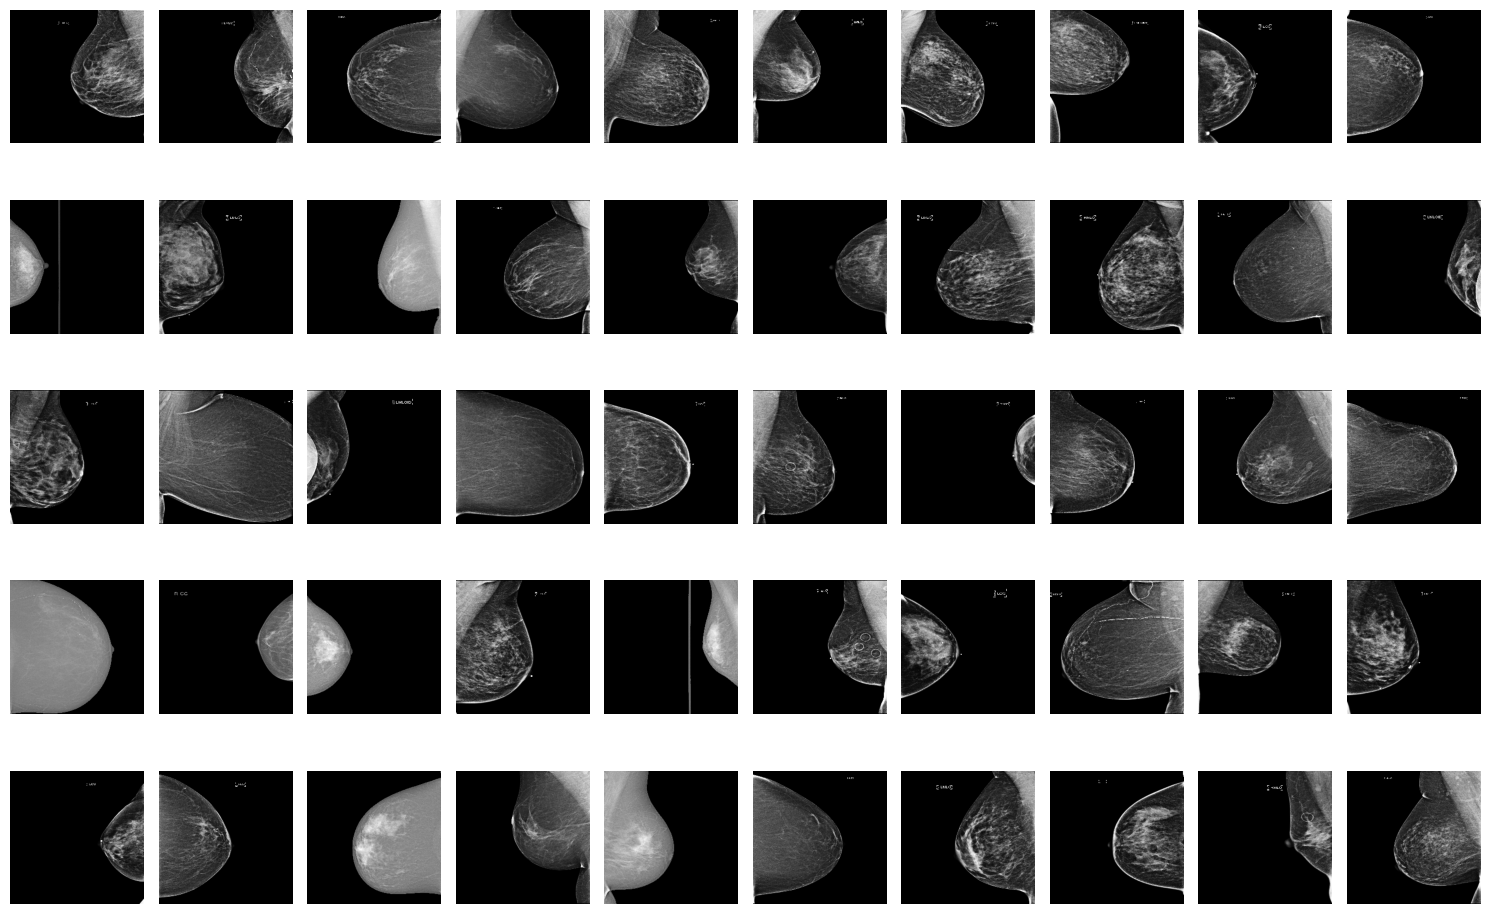

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Get the first 50 image file paths
image_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))
        if len(image_files) >= 50:  # Stop after collecting 50 images
            break
    if len(image_files) >= 50:
        break

# Display the first 50 images
fig, axes = plt.subplots(5, 10, figsize=(15, 10))  # Create a 5x10 grid
axes = axes.flatten()

for img_path, ax in zip(image_files, axes):
    img = Image.open(img_path).convert("L")  # Convert to grayscale
    ax.imshow(img, cmap="gray")  # Display as grayscale
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
import os
from PIL import Image

# Paths
dataset_path = "/content"
aligned_dir = os.path.join(dataset_path, "aligned_images")
os.makedirs(aligned_dir, exist_ok=True)

def classify_breast(image):
    # Convert image to numpy array
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compute average pixel intensity (or other heuristics) for comparison
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    # Example heuristic: If left side is brighter, it's a left breast image
    if left_mean > right_mean:
        return "LEFT"
    else:
        return "RIGHT"

In [12]:
# Process images
for img_file in os.listdir(dataset_path):
    if img_file.endswith(".png"):
        img_path = os.path.join(dataset_path, img_file)

        image = Image.open(img_path).convert("L")

        # Classify the image
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal flip

        # Save the aligned image
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

print(f"Alignment complete. Aligned images are saved in '{aligned_dir}'.")

Alignment complete. Aligned images are saved in '/content/aligned_images'.


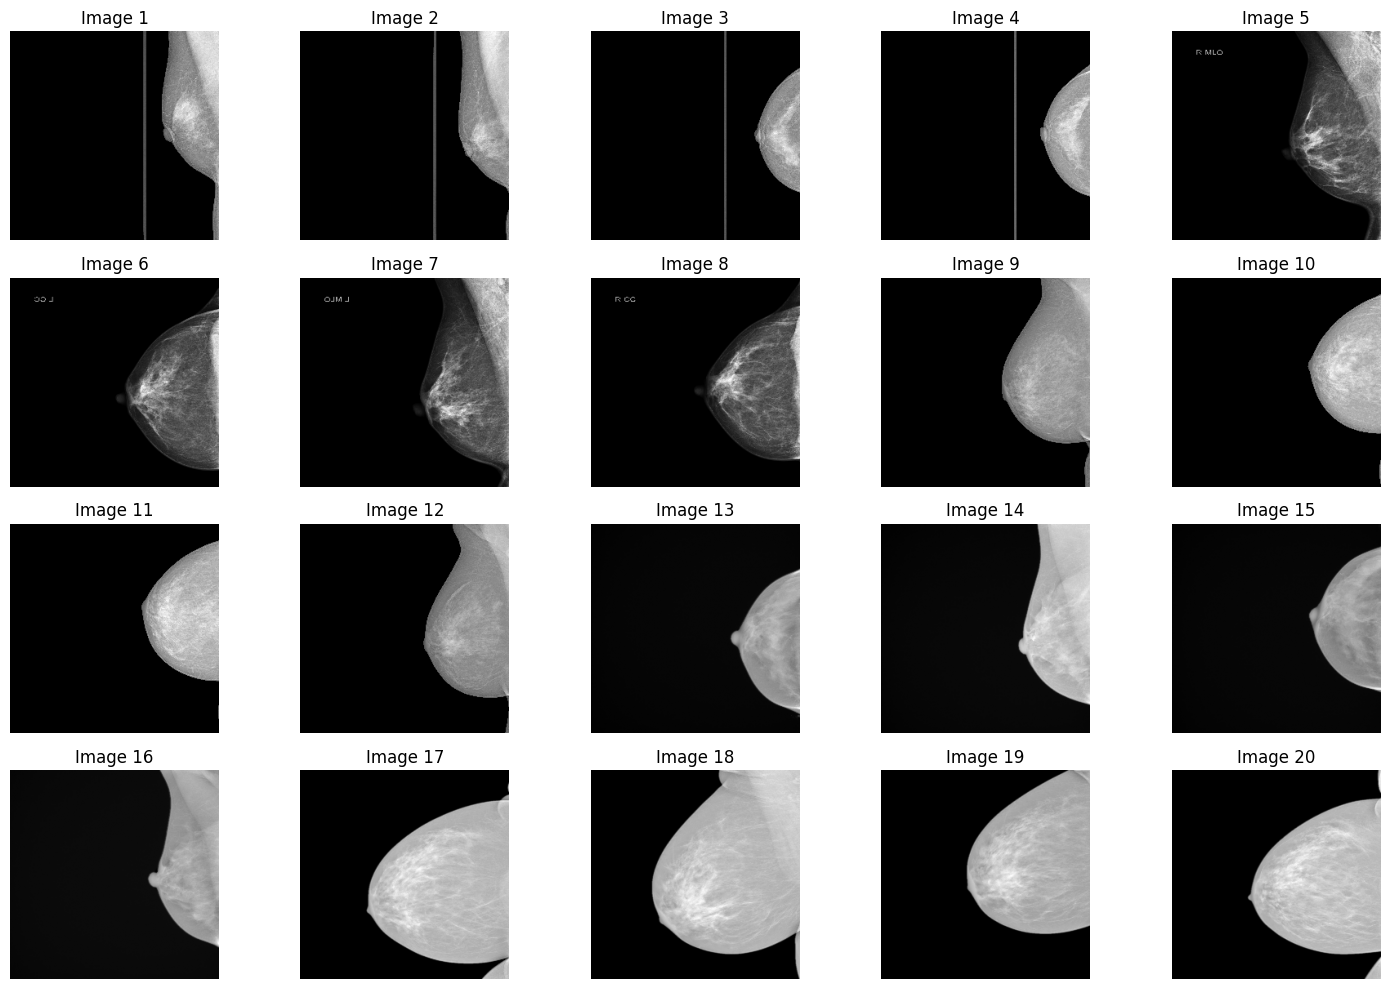

In [13]:
# Directory with aligned images
aligned_dir = "/content/aligned_images"

# Get the first 20 images
image_files = [f for f in os.listdir(aligned_dir) if f.endswith(".png")]
image_files = sorted(image_files)[:20]  # Sort to ensure consistent order

# Plot the images
plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(aligned_dir, img_file)
    image = Image.open(img_path)

    # Display each image in a grid
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns for 20 images
    plt.imshow(image, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of bright, high-contrast images: 12714


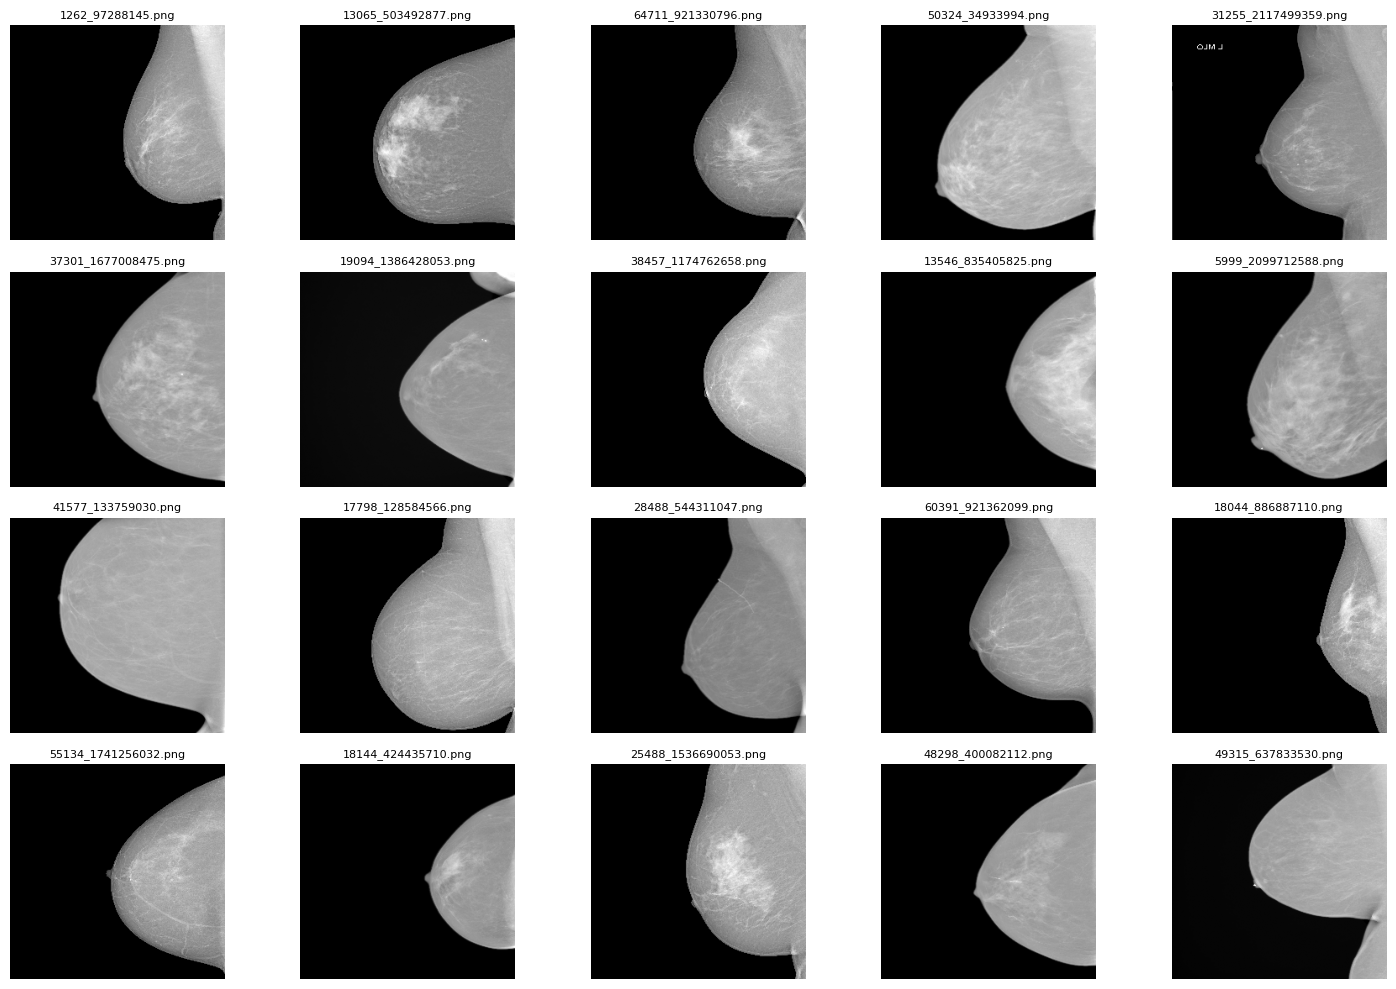

In [14]:
dataset_dir = "/content/aligned_images"

# thresholds for detecting high-contrast and bright images
brightness_threshold = 0.5  # Pixels brighter than this are considered white - increase for very bright regions
region_brightness_ratio = 0.15  # Proportion of image that must be bright to qualify - decrease if missing images with smaller bright areas
contrast_threshold = 0.2  # Minimum contrast difference to identify bright regions - decrease to include images with slightly less contrast

# function to identify high-contrast, bright images
def find_bright_contrast_images(dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold):
    bright_images = []
    bright_filenames = []

    for filename in os.listdir(dataset_dir):
        if filename.endswith((".png")):
            # Load image
            img_path = os.path.join(dataset_dir, filename)
            img = Image.open(img_path)

            # Normalize pixel values to [0, 1]
            img_array = np.array(img) / 255.0

            # Calculate overall contrast (difference between max and min pixel intensities)
            contrast = np.max(img_array) - np.min(img_array)

            # Identify bright pixels
            bright_pixels = img_array >= brightness_threshold
            bright_pixel_ratio = np.sum(bright_pixels) / img_array.size

            # Check conditions for bright and high-contrast images
            if contrast > contrast_threshold and bright_pixel_ratio > region_brightness_ratio:
                bright_images.append(img)
                bright_filenames.append(filename)

    return bright_images, bright_filenames

# Identify high-intensity and high-contrast images
bright_images, bright_filenames = find_bright_contrast_images(
    dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold
)

# Print the number of bright, high-contrast images
print(f"Number of bright, high-contrast images: {len(bright_images)}")

# Display the first 20 bright images
num_to_display = min(20, len(bright_images))
plt.figure(figsize=(15, 10))
for i in range(num_to_display):
    plt.subplot(4, 5, i + 1)  # 4 rows x 5 columns
    plt.imshow(bright_images[i], cmap="gray")
    plt.title(bright_filenames[i], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Remove identified images from the dataset directory
for filename in bright_filenames:
    img_path = os.path.join(dataset_dir, filename)
    try:
        os.remove(img_path)  # Delete the file
        if random.randint(0,300) == 123:
          print(f"Deleted {filename}")
    except Exception as e:
        print(f"Error deleting {filename}: {e}")

# Print the total number of images remaining in the directory
remaining_images = [filename for filename in os.listdir(dataset_dir) if filename.endswith((".png"))]
print(f"Total number of images remaining: {len(remaining_images)}")

Streaming output truncated to the last 5000 lines.
Error deleting 35994_1007470851.png: name 'random' is not defined
Error deleting 61486_166381006.png: name 'random' is not defined
Error deleting 43048_2085591686.png: name 'random' is not defined
Error deleting 38466_1630152471.png: name 'random' is not defined
Error deleting 35104_1219773530.png: name 'random' is not defined
Error deleting 21342_1809217939.png: name 'random' is not defined
Error deleting 28008_51821090.png: name 'random' is not defined
Error deleting 4897_1671045322.png: name 'random' is not defined
Error deleting 48612_1285210978.png: name 'random' is not defined
Error deleting 64372_101452300.png: name 'random' is not defined
Error deleting 4873_770401243.png: name 'random' is not defined
Error deleting 33639_1212582559.png: name 'random' is not defined
Error deleting 2641_196635163.png: name 'random' is not defined
Error deleting 7493_1950616853.png: name 'random' is not defined
Error deleting 59628_713557806.png:

In [16]:
# Set parameters
n_epochs = 25  # Number of epochs of training
batch_size = 32  # Size of the batches
lr_g = 2e-4  # Adam: learning rate for generator
lr_d = 1e-4 # learning rate for discriminator
b1 = 0.9  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 256  # Dimensionality of the latent space
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 10  # Number of training steps for discriminator per iteration
clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 10.0 # Define the gradient penalty weight

In [17]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [18]:
# class Generator(nn.Module):
#     def __init__(self, latent_dim, img_shape):
#         super(Generator, self).__init__()
#         self.img_shape = img_shape

#         def block(in_feat, out_feat, normalize=True):
#             layers = [nn.Linear(in_feat, out_feat)]
#             if normalize:
#                 layers.append(nn.BatchNorm1d(out_feat, 0.8))
#             layers.append(nn.LeakyReLU(0.2, inplace=True))
#             return layers

#         self.model = nn.Sequential(
#             *block(latent_dim, 128, normalize=False),
#             *block(128, 256),
#             *block(256, 512),
#             *block(512, 1024),
#             nn.Linear(1024, int(np.prod(img_shape))),
#             nn.Tanh()
#         )

#     def forward(self, z):
#         img = self.model(z)
#         img = img.view(img.shape[0], 1, *self.img_shape)  # Ensure channel is 1 for grayscale
#         return img

In [19]:
# class Discriminator(nn.Module):
#     def __init__(self, img_shape):
#         super(Discriminator, self).__init__()
#         img_flat_dim = int(np.prod(img_shape))  # This should be 65536 for 256x256 images

#         self.model = nn.Sequential(
#             nn.Linear(img_flat_dim, 512),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Linear(512, 256),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Linear(256, 1),  # Output a single value (real/fake)
#         )

#     def forward(self, img):
#         img_flat = img.view(img.shape[0], -1)  # Flatten the image
#         validity = self.model(img_flat)
#         return validity

In [20]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        channels, img_size, _ = img_shape  # (1, 256, 256)

        # Define initial size (downscaled version of the target)
        self.init_size = img_size // 32  # Start with 8x8 feature maps

        # Fully connected layer to expand the latent space
        self.fc = nn.Linear(latent_dim, 512 * self.init_size * self.init_size)

        # Convolutional layers to upscale to 256x256
        self.model = nn.Sequential(
            nn.BatchNorm2d(512),

            # 8x8 → 16x16
            nn.ConvTranspose2d(512, 256, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 → 32x32
            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 → 64x64
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64 → 128x128
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 128x128 → 256x256
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Final 3x3 conv layer for fine details
            nn.Conv2d(64, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # Output in range [-1,1]
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.shape[0], 512, self.init_size, self.init_size)  # Reshape to feature map
        img = self.model(out)
        return img

# Create the generator
generator = Generator(latent_dim, img_shape)

# Generate a random latent vector and test the output shape
z = torch.randn(1, latent_dim)
output = generator(z)
print("Generated image shape:", output.shape)  # Expected: torch.Size([1, 1, 256, 256])

Generated image shape: torch.Size([1, 1, 256, 256])


In [21]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        channels, img_size, _ = img_shape  # (1, 256, 256)

        self.model = nn.Sequential(
            # 256x256 → 128x128
            nn.Conv2d(channels, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),

            # 128x128 → 64x64
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 64x64 → 32x32
            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 → 16x16
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 → 8x8
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # Flatten for final classification
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 1),  # Adjusted for 256x256 images
            nn.Sigmoid()  # Outputs probability [0,1]
        )

    def forward(self, img):
        return self.model(img)

# Create the discriminator
discriminator = Discriminator(img_shape)

# Test with a random image tensor
img_sample = torch.randn(1, 1, 256, 256)
output = discriminator(img_sample)
print("Discriminator output shape:", output.shape)  # Expected: torch.Size([1, 1])

Discriminator output shape: torch.Size([1, 1])


In [22]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Directory of the dataset
dataset_dir = "/content/aligned_images"

# Custom Dataset Class to load images with on-the-fly augmentations
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]  # Filter PNG files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Define on-the-fly augmentation pipeline
transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),  # Randomly rotate between -15° and 15°
    transforms.CenterCrop(224),  # Center crop
    transforms.Resize(256),  # Resize back to 256x256
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create Dataset and DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test one batch to check transformations
for batch in dataloader:
    print(batch.shape)  # Expected: (32, 1, 256, 256) for grayscale images
    break

torch.Size([32, 1, 256, 256])


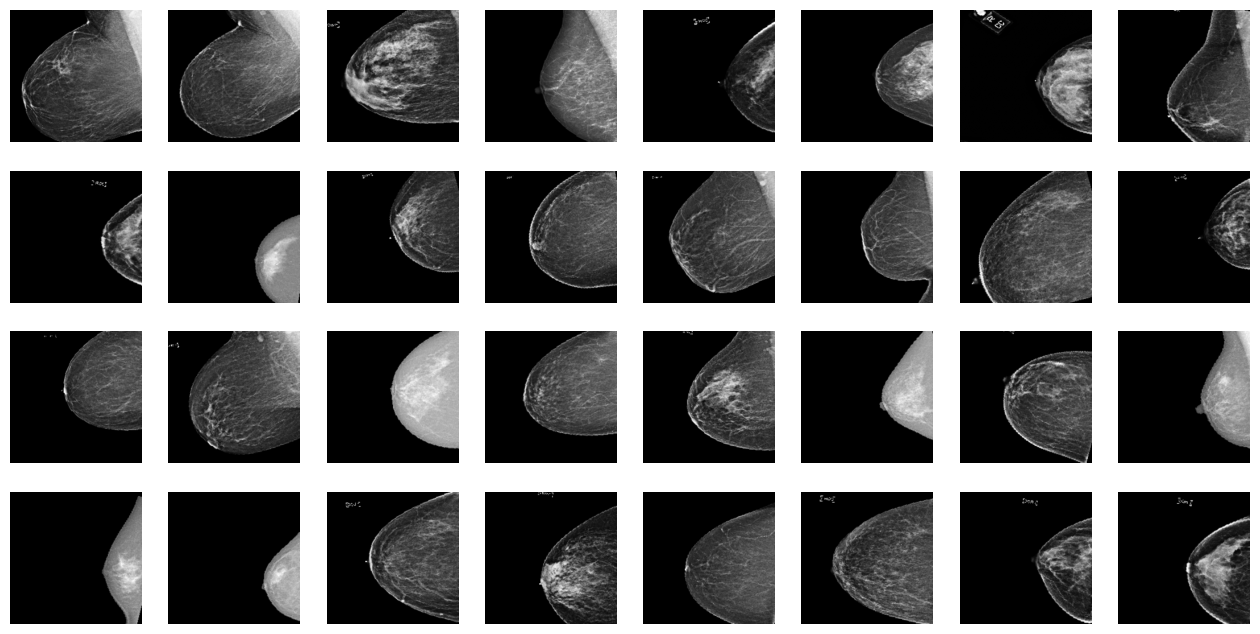

In [23]:
import matplotlib.pyplot as plt

# Function to unnormalize image
def unnormalize(tensor, mean, std):
    """
    Unnormalize the tensor to the range [0, 1].
    """
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return tensor * std + mean

# Visualizing one batch of images
def visualize_batch(dataloader):
    # Get one batch from the dataloader
    images = next(iter(dataloader))  # Get one batch of images

    # Unnormalize the images (since you used Normalize([0.5], [0.5]))
    images = unnormalize(images, mean=[0.5], std=[0.5])

    # Plot the images in the batch
    batch_size = images.size(0)
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))  # Adjust grid size to display 32 images (4x8 grid)

    for i in range(batch_size):
        ax = axes[i // 8, i % 8]  # Find the correct subplot position
        ax.imshow(images[i].squeeze(), cmap='gray')  # Remove the channel dimension and display as grayscale
        ax.axis('off')  # Hide axes

    plt.show()

visualize_batch(dataloader)

In [24]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Generated images shape: torch.Size([7, 1, 256, 256])


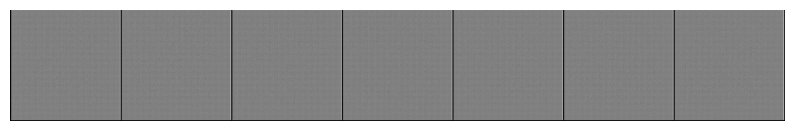

[Epoch 1/201] [D loss: 0.601942] [G loss: -0.206990]
[Epoch 2/201] [D loss: -0.234056] [G loss: -0.014310]
[Epoch 3/201] [D loss: -0.955392] [G loss: -0.000813]
[Epoch 4/201] [D loss: 0.574569] [G loss: -0.002462]
[Epoch 5/201] [D loss: 4.195991] [G loss: -0.026847]
Generated images shape: torch.Size([7, 1, 256, 256])


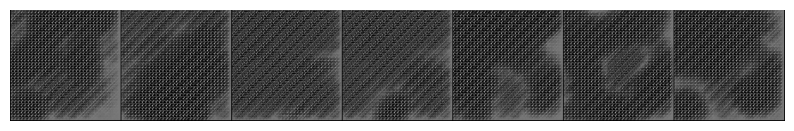

[Epoch 6/201] [D loss: 0.670408] [G loss: -0.248081]


In [ ]:
import torch
from torch.autograd import Variable
import numpy as np

checkpoint_interval = 10

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(b1, b2))

# Learning Rate Scheduler (Cosine Annealing)
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------

batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1,n_epochs+1):
    if epoch % 5 == 1:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)
    for i, imgs in enumerate(dataloader):

        # Ensure the tensors are float32 and move to device
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))

        # Generate a batch of images
        fake_imgs = generator(z)

        # Reshape fake images to match the shape of real images
        fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

        # Real images
        real_validity = discriminator(real_imgs)
        # Fake images
        fake_validity = discriminator(fake_imgs)
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        # Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        # Backprop and optimizer step
        d_loss.backward()
        d_loss_val = d_loss.item()

        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the generator every n_critic steps
        if i % n_critic == 0:

            # -----------------
            #  Train Generator
            # -----------------

            # Generate a batch of images
            fake_imgs = generator(z)

            # Reshape fake images to match the shape of real images
            fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

            # Loss measures generator's ability to fool the discriminator
            # Train on fake images
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

            # Backprop and optimizer step
            g_loss.backward()
            optimizer_G.step()

            # print(
            #     "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
            #     % (epoch, n_epochs, i, len(dataloader), d_loss.item(), g_loss.item())
            # )
            g_loss_val = g_loss.item()

            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

        # Optional: Save checkpoint of model periodically (every few epochs)
        if epoch % checkpoint_interval == 0 and i == len(dataloader) - 1:
            torch.save(generator.state_dict(), 'generator_checkpoint.pth')
            torch.save(discriminator.state_dict(), 'discriminator_checkpoint.pth')

    print("[Epoch %d/%d] [D loss: %f] [G loss: %f]"
             % (epoch, n_epochs, d_loss_val, g_loss_val)
            )